# Google Search Ranking & Discoverability Capstone

## Abstract

This project develops a machine learning approach for identifying web pages that require content refresh. A rule-based baseline scoring system was first created using visibility, freshness, search position, and content depth signals. A Random Forest classifier was then trained using search performance and engagement features to predict declining pages. The model achieved an accuracy of 69.37% with balanced precision and recall. The resulting ranked recommendations provide data-driven support for prioritizing content updates.

# Introduction

Keeping website content updated is important for maintaining search visibility and user engagement. This project analyzes anonymized search performance data from the FlyRank internship dataset to identify pages that should be refreshed.

The workflow includes exploratory data analysis, feature engineering, baseline scoring, machine learning, and recommendation generation.

**1. Load Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("content_refresh_anonymized.csv")

In [ ]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [ ]:
df.shape

(30000, 44)

In [ ]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [ ]:
df.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,0.991933,0.204500,4.033500,61.454033,13.096333,1429.058733,4.933867,14.114267,1783.078500,5.435100,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,4.359576,1.363601,22.335179,32.689245,17.307759,5643.852081,23.929393,39.036371,6150.429511,28.358673,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,31.000000,2.000000,10.000000,0.000000,0.000000,19.000000,0.000000,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,0.000000,0.000000,1.000000,81.000000,6.000000,139.000000,0.000000,3.000000,210.000000,0.000000,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,1.000000,0.000000,3.000000,88.000000,16.000000,768.000000,2.000000,12.000000,1143.000000,2.000000,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,290.000000,64.000000,2605.000000,88.000000,90.000000,238796.000000,1176.000000,1081.000000,218786.000000,1627.000000,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


## Dataset Description

The dataset contains anonymized search performance and engagement metrics for web content.

Key variables include:

- Search Volume
- Impressions
- Clicks
- CTR
- Average Position
- Sessions
- Engagement Rate
- Scroll Rate
- Content Age
- Days Since Last Update

These features are used to analyze content performance and build predictive models.

**2. Exploratory Data Analysis (EDA)**

In [ ]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0
provider_used,21438
word_count_tier,7699
char_count,7699
word_count,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
competition,2468


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Count pages in each trend category
df["trend_direction"].value_counts()

,count
trend_direction,
down,16262
stable,5962
up,4388
new,2236
flat,1152


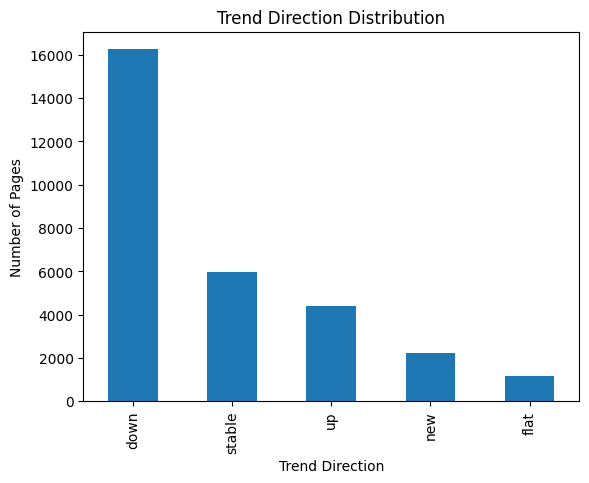

In [ ]:
import matplotlib.pyplot as plt

df["trend_direction"].value_counts().plot(kind="bar")

plt.title("Trend Direction Distribution")
plt.xlabel("Trend Direction")
plt.ylabel("Number of Pages")
plt.show()

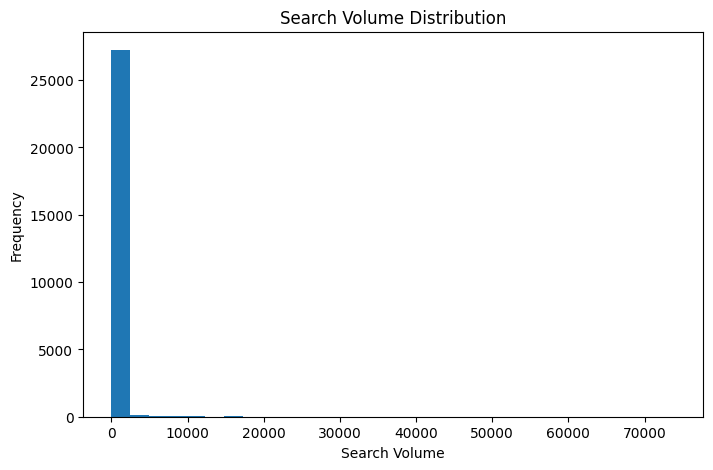

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["search_volume"], bins=30)

plt.title("Search Volume Distribution")
plt.xlabel("Search Volume")
plt.ylabel("Frequency")

plt.show()

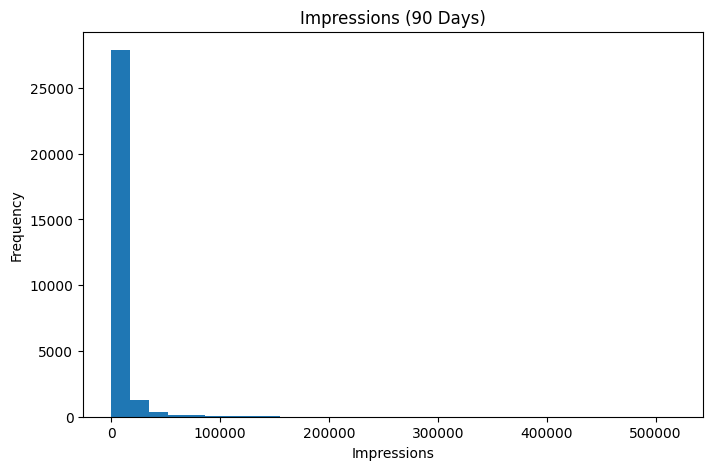

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["impressions_90d"], bins=30)

plt.title("Impressions (90 Days)")
plt.xlabel("Impressions")
plt.ylabel("Frequency")

plt.show()

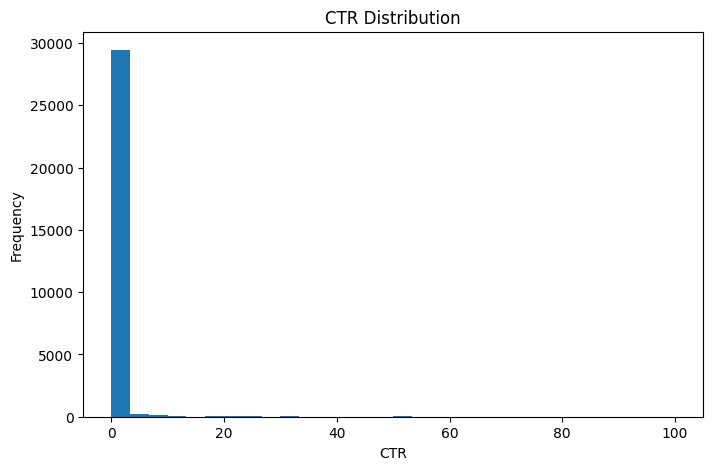

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["ctr"], bins=30)

plt.title("CTR Distribution")
plt.xlabel("CTR")
plt.ylabel("Frequency")

plt.show()

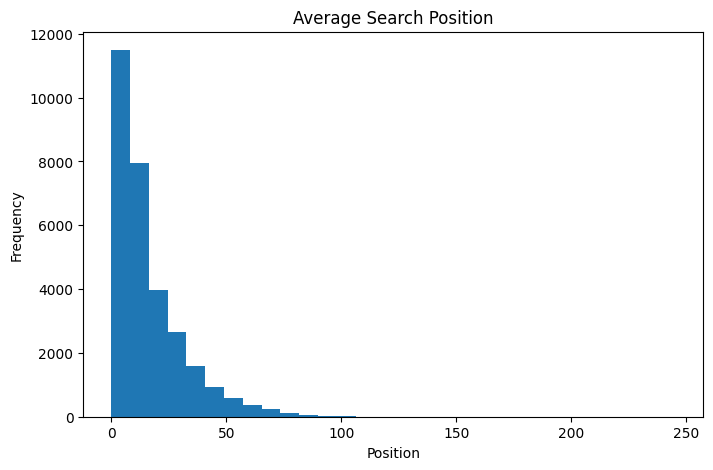

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["avg_position"], bins=30)

plt.title("Average Search Position")
plt.xlabel("Position")
plt.ylabel("Frequency")

plt.show()

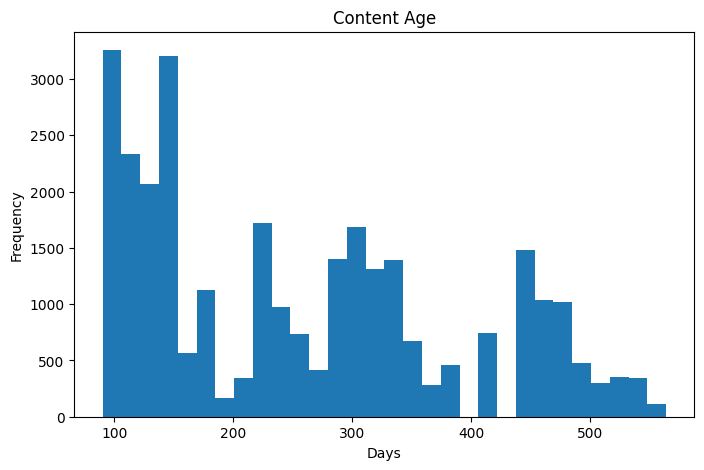

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["content_age_days"], bins=30)

plt.title("Content Age")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

corr

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
search_volume,1.000000,0.049887,0.042085,-0.019458,-0.023876,0.001203,-0.011260,-0.015152,-0.013171,-0.013394,-0.009712,-0.012218,-0.009163,0.009828,-0.018079,0.001028,-0.009635,-0.010160,-0.001542,-0.010893,-0.006994,0.090720,0.085458,-0.003237,-0.003430,0.045354,-0.010146,-0.013808,-0.003250,0.002515
competition,0.049887,1.000000,0.302415,-0.201019,-0.185828,-0.053530,-0.032160,-0.071989,-0.063738,-0.065026,-0.019755,-0.030091,-0.035142,-0.049587,-0.088844,-0.040937,-0.031902,-0.064731,-0.051569,-0.030041,-0.036503,0.053409,0.024922,-0.033763,-0.019170,0.049036,0.000694,-0.038098,0.007956,0.014426
cpc,0.042085,0.302415,1.000000,-0.090349,-0.082660,-0.025599,-0.023418,-0.028970,-0.029505,-0.029417,-0.014396,-0.008520,-0.014667,-0.036899,-0.046081,-0.017472,-0.022812,-0.028029,-0.025444,-0.023114,-0.023001,0.072067,0.056036,-0.003417,-0.002252,0.044194,0.004044,-0.018809,-0.002414,0.004839
word_count,-0.019458,-0.201019,-0.090349,1.000000,0.939252,0.163345,0.091271,0.359895,0.332124,0.340521,0.134550,0.207586,0.149442,0.298670,0.390686,0.117150,0.096726,0.338535,0.152512,0.087559,0.198678,-0.121030,-0.028283,0.306540,-0.118636,0.123813,-0.063045,-0.160688,0.007006,-0.009211
char_count,-0.023876,-0.185828,-0.082660,0.939252,1.000000,0.144301,0.081121,0.323351,0.298740,0.306716,0.118265,0.188575,0.133503,0.251493,0.344647,0.105004,0.086310,0.307288,0.135205,0.078983,0.178569,-0.147486,-0.061397,0.270742,-0.108063,0.099400,-0.061566,-0.139467,0.007186,-0.006969
impressions_90d,0.001203,-0.053530,-0.025599,0.163345,0.144301,1.000000,0.696281,0.582563,0.629925,0.620974,0.499833,0.216795,0.302351,0.240042,0.600219,0.918243,0.686219,0.601819,0.972549,0.661043,0.523721,-0.000743,0.007532,0.081597,-0.018950,-0.070786,0.024318,-0.096905,-0.008518,0.024187
clicks_90d,-0.011260,-0.032160,-0.023418,0.091271,0.081121,0.696281,1.000000,0.699304,0.765661,0.749002,0.733750,0.154764,0.465027,0.166013,0.561744,0.637776,0.946757,0.702011,0.693319,0.976504,0.694579,-0.022678,-0.016885,0.044444,0.010609,-0.099304,0.030527,-0.062235,-0.010369,-0.001778
pageviews_90d,-0.015152,-0.071989,-0.028970,0.359895,0.323351,0.582563,0.699304,1.000000,0.973897,0.971213,0.665992,0.349781,0.547114,0.232135,0.687740,0.533723,0.681475,0.906779,0.563156,0.665947,0.783392,-0.040271,-0.016075,0.186787,-0.004177,-0.017177,0.006455,-0.113303,-0.006670,-0.001189
sessions_90d,-0.013171,-0.063738,-0.029505,0.332124,0.298740,0.629925,0.765661,0.973897,1.000000,0.998111,0.679158,0.312654,0.617926,0.238194,0.691587,0.573385,0.733911,0.877586,0.613126,0.733061,0.837117,-0.028436,-0.005952,0.161640,-0.006055,-0.032629,0.005895,-0.110595,-0.010088,-0.003162
users_90d,-0.013394,-0.065026,-0.029417,0.340521,0.306716,0.620974,0.749002,0.971213,0.998111,1.000000,0.672445,0.311512,0.641261,0.237656,0.684405,0.563929,0.717214,0.867246,0.604511,0.718235,0.843560,-0.027497,-0.004266,0.165442,-0.006642,-0.030062,0.005220,-0.109930,-0.009936,-0.003704


In [ ]:
df.nlargest(10, "ctr")[["content_id", "ctr", "search_volume"]]

,content_id,ctr,search_volume
240,content_006b16e7a2e7,100.0,0.0
4606,content_3f3576c295f5,100.0,0.0
6473,content_cfa4d9f1bf0a,100.0,NaN
7514,content_b1e4f7904d85,100.0,NaN
13661,content_bf398aa7400e,100.0,NaN
18825,content_98458bafe297,100.0,NaN
19341,content_4272d3a330a3,100.0,0.0
19598,content_a84e013a5f94,100.0,NaN
21147,content_6016b918a48f,100.0,NaN
22607,content_bc2c0c7243df,100.0,NaN


In [ ]:
df.nlargest(10, "search_volume")[["content_id", "search_volume"]]

,content_id,search_volume
12140,content_ef99c4abd9ab,74000.0
6972,content_bf67a444faef,60500.0
17907,content_5ec29ae79c60,60500.0
18701,content_deb54e9e19cd,60500.0
28282,content_454cc6654c6e,60500.0
8055,content_cd6760921db8,49500.0
13502,content_f76ccf7a7834,49500.0
16005,content_83e3da1394ac,49500.0
22788,content_ee4630879d03,49500.0
2815,content_7868341d97dd,40500.0


In [ ]:
df.nlargest(10, "impressions_90d")[["content_id","impressions_90d"]]

,content_id,impressions_90d
6653,content_5fe46e04994d,517715
17812,content_aaef01a50def,517109
26844,content_8c19996aa890,509252
19636,content_2cb567c3c89b,497727
21819,content_4c36c775b818,463103
29400,content_2dba2b1f9536,443434
29879,content_1a9e894be2e2,416180
13537,content_2c2606c5d176,347399
18870,content_db5989a78dd3,345111
14090,content_44e481c8f55b,312694


## EDA Observations

- The dataset contains **30,000 rows** and **44 columns** with both numerical and categorical features.
- No duplicate records were found.
- Some columns contain missing values and will be handled during preprocessing.
- Search volume and impressions are right-skewed, with most pages having lower values.
- CTR and average position vary across content pages, indicating different levels of search performance.
- The `trend_direction` column shows pages with improving, stable, and declining trends.
- Overall, the dataset is suitable for preprocessing and machine learning.

**3. Data Preprocessing & Feature Engineering**

In [ ]:
# Create target variable
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

# Check the distribution
df["is_declining_label"].value_counts()

,count
is_declining_label,
1,16262
0,13738


**Target Variable**

The target variable `is_declining_label` was created from the `trend_direction` column.

- 1 = Declining content
- 0 = Stable or improving content

This binary label will be used for model training.

In [ ]:
numeric_columns = [
    "search_volume", "competition", "cpc",
    "word_count", "char_count",
    "impressions_90d", "clicks_90d",
    "pageviews_90d", "sessions_90d",
    "users_90d", "engaged_sessions_90d",
    "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions",
    "impressions_last_30d", "clicks_last_30d",
    "sessions_last_30d", "impressions_prev_30d",
    "clicks_prev_30d", "sessions_prev_30d",
    "content_age_days", "age_tier_order",
    "days_since_last_update",
    "ctr", "avg_position",
    "engagement_rate", "scroll_rate",
    "ai_traffic_pct", "trend_pct"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
# Handle Missing Values
# Numeric columns
df[numeric_columns] = df[numeric_columns].fillna(0)

# Categorical columns
categorical_columns = df.select_dtypes(include="object").columns

df[categorical_columns] = df[categorical_columns].fillna("unknown")

In [ ]:
# Remove Duplicate Content
df = df.drop_duplicates(subset=["content_id"])

In [ ]:
df = df[df["impressions_90d"] > 0]

df = df[df["content_age_days"] >= 90]

In [ ]:
# Create Engineered Features

import numpy as np

df["log_impressions_90d"] = np.log1p(df["impressions_90d"])

df["log_clicks_90d"] = np.log1p(df["clicks_90d"])

df["log_sessions_90d"] = np.log1p(df["sessions_90d"])

df["log_ai_sessions_90d"] = np.log1p(df["ai_sessions_90d"])

df["has_clicks"] = (df["clicks_90d"] > 0).astype(int)

df["has_ai_sessions"] = (df["ai_sessions_90d"] > 0).astype(int)

df["measurable_opportunity"] = (
    (df["impressions_90d"] > 0) &
    (df["content_age_days"] >= 90)
).astype(int)

In [ ]:
# Check Final Dataset
df.shape

(30000, 52)

In [ ]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,is_declining_label,log_impressions_90d,log_clicks_90d,log_sessions_90d,log_ai_sessions_90d,has_clicks,has_ai_sessions,measurable_opportunity
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,unknown,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4,1,8.243808,3.401197,2.890372,0.0,1,0,1
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,unknown,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7,1,9.636980,2.079442,2.302585,0.0,1,0,1
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,unknown,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9,1,9.440023,2.484907,2.484907,0.0,1,0,1
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,0.0,0.0,unknown,unknown,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,unknown,unknown,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8,0,9.371779,4.077537,4.369448,0.0,1,0,1
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,unknown,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7,1,9.859588,3.218876,4.983607,0.0,1,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 52 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           30000 non-null  float64
 3   competition             30000 non-null  float64
 4   competition_level       30000 non-null  object 
 5   cpc                     30000 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             30000 non-null  object 
 8   word_count              30000 non-null  float64
 9   char_count              30000 non-null  float64
 10  provider_used           30000 non-null  object 
 11  model_used              30000 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

## Data Preprocessing Summary

- Created the target variable (`is_declining_label`) from `trend_direction`.
- Converted numerical columns to numeric data types.
- Filled missing values in numerical and categorical columns.
- Removed duplicate content records.
- Filtered pages with zero impressions and pages newer than 90 days.
- Created engineered features using logarithmic transformations and binary indicators.

**4. Build the Baseline Action Score**

In [ ]:
# Normalize selected features
df["norm_impressions"] = (
    (df["impressions_90d"] - df["impressions_90d"].min()) /
    (df["impressions_90d"].max() - df["impressions_90d"].min())
)

df["norm_position"] = (
    (df["avg_position"] - df["avg_position"].min()) /
    (df["avg_position"].max() - df["avg_position"].min())
)

df["norm_ctr"] = (
    (df["ctr"] - df["ctr"].min()) /
    (df["ctr"].max() - df["ctr"].min())
)

df["norm_age"] = (
    (df["days_since_last_update"] - df["days_since_last_update"].min()) /
    (df["days_since_last_update"].max() - df["days_since_last_update"].min())
)

In [ ]:
# Create Baseline Score
df["baseline_score"] = (
    0.35 * df["norm_impressions"] +
    0.30 * df["norm_position"] +
    0.20 * (1 - df["norm_ctr"]) +
    0.15 * df["norm_age"]
)

In [ ]:
# Create Action Labels
def assign_action(score):
    if score >= 0.75:
        return "Refresh Now"
    elif score >= 0.50:
        return "Review Soon"
    else:
        return "Monitor"

df["action"] = df["baseline_score"].apply(assign_action)

In [ ]:
# Create Reason Codes
def reason_code(row):
    reasons = []

    if row["ctr"] < 0.05:
        reasons.append("Low CTR")

    if row["avg_position"] > 20:
        reasons.append("Poor Position")

    if row["days_since_last_update"] > 180:
        reasons.append("Old Content")

    if row["impressions_90d"] > 1000:
        reasons.append("High Visibility")

    return ", ".join(reasons) if reasons else "No major issue"

df["reason_code"] = df.apply(reason_code, axis=1)

In [ ]:
# Sort the Queue
baseline_queue = df.sort_values(
    by="baseline_score",
    ascending=False
)

baseline_queue.head(10)

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,norm_impressions,norm_position,norm_ctr,norm_age,baseline_score,action,reason_code
6653,content_5fe46e04994d,client_4e07408562,1900.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,NaN,gpt-4o-mini,517715,741,580,520,504,22,2,156,88,88,120791,220,145,218786,250,181,537,365+,6,104,91-180,NaN,NaN,0.14,4.2,4.23,26.90,0.38,excellent,page_1,down,-44.8,1.000000,0.017143,0.0014,0.276882,0.596395,Review Soon,High Visibility
19636,content_2cb567c3c89b,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,6183.0,39587.0,NaN,gemini-3-flash-preview,497727,487,1703,910,881,53,11,96,88,89,197677,275,465,160641,132,230,153,91-180,4,48,31-90,3500+,25000+,0.10,22.2,5.82,5.64,1.21,excellent,page_3_5,up,23.1,0.961392,0.090612,0.0010,0.126344,0.582422,Review Soon,"Poor Position, High Visibility"
29400,content_2dba2b1f9536,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,7676.0,48015.0,NaN,gemini-3-flash-preview,443434,910,5998,4218,4153,115,18,466,88,90,139891,314,1004,137909,323,575,299,181-365,5,104,91-180,3500+,25000+,0.21,27.9,2.73,7.77,0.43,excellent,page_3_5,stable,1.4,0.856521,0.113878,0.0021,0.276882,0.575058,Review Soon,"Poor Position, High Visibility"
17812,content_aaef01a50def,client_19581e27de,4400.0,0.05,LOW,0.11,keyword article,informational,NaN,NaN,NaN,NaN,517109,1270,1804,1527,1444,37,0,86,88,76,170559,435,647,177601,461,645,445,365+,6,22,0-30,NaN,NaN,0.25,5.4,2.42,4.77,0.00,excellent,page_1,stable,-4.0,0.998829,0.022041,0.0025,0.056452,0.564170,Review Soon,High Visibility
26844,content_8c19996aa890,client_4e07408562,70.0,0.01,LOW,0.00,keyword article,informational,2895.0,19343.0,NaN,gemini-3-flash-preview,509252,785,624,571,546,67,0,100,88,86,89463,251,177,161284,389,302,445,365+,6,20,0-30,2000-3500,15000-25000,0.15,2.5,11.73,16.03,0.00,excellent,top_3,down,-44.5,0.983653,0.010204,0.0015,0.051075,0.554701,Review Soon,High Visibility
21819,content_4c36c775b818,client_4e07408562,40.0,0.00,LOW,0.00,keyword article,informational,3097.0,20514.0,NaN,gemini-3-flash-preview,463103,1889,1223,1114,1082,126,0,221,88,89,83723,548,350,125416,662,354,445,365+,6,20,0-30,2000-3500,15000-25000,0.41,2.3,11.31,18.07,0.00,excellent,top_3,down,-33.2,0.894513,0.009388,0.0041,0.051075,0.522737,Review Soon,High Visibility
24445,content_661e1745db72,client_e29c9c180c,2400.0,0.00,LOW,0.12,keyword article,commercial,1385.0,8651.0,NaN,gemini-2.5-flash,1,0,2,2,2,0,0,1,1,2,1,0,0,0,0,1,311,181-365,5,20,0-30,1000-2000,8000-15000,0.00,245.0,0.00,50.00,0.00,low,deep,new,NaN,0.000000,1.000000,0.0000,0.051075,0.507661,Review Soon,"Low CTR, Poor Position"
29879,content_1a9e894be2e2,client_19581e27de,70.0,0.07,LOW,0.10,keyword article,transactional,NaN,NaN,NaN,NaN,416180,944,1288,1140,1120,27,0,64,88,76,107986,247,382,147889,325,488,482,365+,6,22,0-30,NaN,NaN,0.23,4.0,2.37,4.97,0.00,excellent,page_1,down,-27.0,0.803878,0.016327,0.0023,0.056452,0.494263,Monitor,High Visibility
13537,content_2c2606c5d176,client_19581e27de,590.0,0.18,LOW,0.31,keyword article,commercial,NaN,NaN,NaN,NaN,347399,1854,2501,2146,2025,28,0,82,88,76,104248,578,788,164079,859,1070,362,181-365,5,104,91-180,NaN,NaN,0.53,4.2,1.30,3.28,0.00,excellent,page_1,down,-36.5,0.671023,0.017143,0.0053,0.276882,0.480473,Monitor,High Visibility
26798,content_b28d1efd668f,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,transactional,6901.0,44938.0,

In [ ]:
baseline_queue.to_csv(
    "baseline_action_score.csv",
    index=False
)

In [ ]:
baseline_queue[
    ["content_id",
     "baseline_score",
     "action",
     "reason_code"]
].head(10)

,content_id,baseline_score,action,reason_code
6653,content_5fe46e04994d,0.596395,Review Soon,High Visibility
19636,content_2cb567c3c89b,0.582422,Review Soon,"Poor Position, High Visibility"
29400,content_2dba2b1f9536,0.575058,Review Soon,"Poor Position, High Visibility"
17812,content_aaef01a50def,0.564170,Review Soon,High Visibility
26844,content_8c19996aa890,0.554701,Review Soon,High Visibility
21819,content_4c36c775b818,0.522737,Review Soon,High Visibility
24445,content_661e1745db72,0.507661,Review Soon,"Low CTR, Poor Position"
29879,content_1a9e894be2e2,0.494263,Monitor,High Visibility
13537,content_2c2606c5d176,0.480473,Monitor,High Visibility
26798,content_b28d1efd668f,0.467254,Monitor,"Poor Position, High Visibility"


## Baseline Action Score

A rule-based baseline scoring system was developed to rank content pages for refresh.

The score combines:

- Impressions
- Average Search Position
- Click-Through Rate (CTR)
- Days Since Last Update

Each page is assigned:

- A baseline score
- An action label
- A reason code

This baseline will be compared with the machine learning model in the next stage.

**5. Create the Four Scores**

In [ ]:
# Visibility Score
df["visibility_score"] = df["impressions_90d"].rank(pct=True)

### Visibility Score

The visibility score ranks pages based on their impressions.
Pages with higher impressions receive higher visibility scores because improving high-traffic pages has a greater potential impact.

In [ ]:
# Freshness Risk Score
df["freshness_risk_score"] = df["days_since_last_update"].rank(pct=True)

### Freshness Risk Score

Pages that have not been updated for a long time receive higher freshness risk scores, indicating that they may benefit from a content refresh.

In [ ]:
# Normalize average position
df["position_norm"] = (
    df["avg_position"] - df["avg_position"].min()
) / (
    df["avg_position"].max() - df["avg_position"].min()
)

# Position Opportunity Score
df["position_opportunity_score"] = (
    (1 - df["position_norm"]) *
    df["visibility_score"]
)

### Position Opportunity Score

This score identifies visible pages with ranking opportunities.
Pages with strong visibility and favorable search positions receive higher opportunity scores.

In [ ]:
# Depth Gap Score
df["depth_gap_score"] = (
    1 - df["word_count"].rank(pct=True)
) * df["visibility_score"]

### Depth Gap Score

This score highlights highly visible pages with relatively shorter content, indicating potential opportunities to expand or improve the content.

In [ ]:
# Check the Scores
df[
    [
        "visibility_score",
        "freshness_risk_score",
        "position_opportunity_score",
        "depth_gap_score"
    ]
].head()

,visibility_score,freshness_risk_score,position_opportunity_score,depth_gap_score
0,0.757133,0.336000,0.724376,0.260113
1,0.920800,0.655033,0.844505,0.671989
2,0.903300,0.336000,0.768727,0.251799
3,0.896400,0.588283,0.873716,NaN
4,0.936750,0.122700,0.768517,0.514202


In [ ]:
df["word_count"].isnull().sum()

np.int64(7699)

In [ ]:
df["word_count"] = df["word_count"].fillna(df["word_count"].median())

In [ ]:
df["depth_gap_score"] = (
    1 - df["word_count"].rank(pct=True)
) * df["visibility_score"]

In [ ]:
df[
    [
        "visibility_score",
        "freshness_risk_score",
        "position_opportunity_score",
        "depth_gap_score"
    ]
].head()

,visibility_score,freshness_risk_score,position_opportunity_score,depth_gap_score
0,0.757133,0.336000,0.724376,0.193359
1,0.920800,0.655033,0.844505,0.735842
2,0.903300,0.336000,0.768727,0.187179
3,0.896400,0.588283,0.873716,0.448036
4,0.936750,0.122700,0.768517,0.622642


In [ ]:
# Baseline Refresh Score
df["baseline_refresh_score"] = (
    0.40 * df["visibility_score"] +
    0.30 * df["freshness_risk_score"] +
    0.25 * df["position_opportunity_score"] +
    0.05 * df["depth_gap_score"]
)

# Keep score between 0 and 1
df["baseline_refresh_score"] = df["baseline_refresh_score"].clip(0, 1)

In [ ]:
df["baseline_refresh_score"].describe()

,baseline_refresh_score
count,30000.000000
mean,0.478304
std,0.224780
min,0.011741
25%,0.302479
50%,0.481434
75%,0.660946
max,0.968526


## Baseline Refresh Score

A baseline refresh score was calculated by combining four component scores:

- Visibility Score (40%)
- Freshness Risk Score (30%)
- Position Opportunity Score (25%)
- Depth Gap Score (5%)

Pages with higher scores are considered higher-priority candidates for content refresh.

In [ ]:
def reason_codes(row):
    reasons = []

    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        reasons.append("stale_visible_page")

    if row["trend_direction"].lower() == "down" and row["impressions_90d"] >= 100:
        reasons.append("declining_with_demand")

    if row["word_count"] > 0 and row["word_count"] < 1200 and row["impressions_90d"] >= 250:
        reasons.append("thin_visible_page")

    if row["avg_position"] > 0 and row["avg_position"] <= 10 and row["content_age_days"] >= 180:
        reasons.append("page_one_decay_risk")

    if row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5:
        reasons.append("low_ctr_visible_page")

    if row["sessions_90d"] >= 30 and (
        (row["engagement_rate"] > 0 and row["engagement_rate"] < 30) or
        (row["scroll_rate"] > 0 and row["scroll_rate"] < 30)
    ):
        reasons.append("low_engagement_visible_page")

    if not reasons:
        reasons.append("general_refresh_review")

    return "|".join(reasons)

df["reason_codes"] = df.apply(reason_codes, axis=1)

In [ ]:
df[["reason_codes"]].head(10)

,reason_codes
0,declining_with_demand
1,declining_with_demand
2,declining_with_demand
3,page_one_decay_risk|low_ctr_visible_page|low_e...
4,declining_with_demand|low_engagement_visible_page
5,declining_with_demand|low_ctr_visible_page
6,general_refresh_review
7,general_refresh_review
8,declining_with_demand|low_engagement_visible_page
9,declining_with_demand|page_one_decay_risk|low_...


## Reason Codes

Reason codes were assigned to each page based on predefined business rules.

These codes explain why a page was recommended for refresh, improving the interpretability of the baseline scoring system.

In [ ]:
def suggested_action(row):
    reasons = row["reason_codes"].split("|")

    if "thin_visible_page" in reasons:
        return "expand_and_refresh"

    if "low_ctr_visible_page" in reasons:
        return "refresh_and_review_ctr"

    if (
        "stale_visible_page" in reasons or
        "declining_with_demand" in reasons
    ):
        return "refresh"

    return "monitor"


df["suggested_action_baseline"] = df.apply(
    suggested_action,
    axis=1
)

In [ ]:
df["suggested_action_baseline"].value_counts()

,count
suggested_action_baseline,
monitor,13173
refresh_and_review_ctr,9741
refresh,7004
expand_and_refresh,82


## Suggested Actions

Each page was assigned a recommended action based on its reason codes.

The actions provide simple and interpretable recommendations such as refreshing content, expanding content, reviewing CTR, or monitoring the page.

In [ ]:
df["baseline_rank"] = (
    df["baseline_refresh_score"]
      .rank(method="first", ascending=False)
      .astype(int)
)

In [ ]:
df[["baseline_rank"]].head()

,baseline_rank
0,10240
1,2122
2,7379
3,3141
4,8578


In [ ]:
baseline_queue = df[
    [
        "content_id",
        "client_id",
        "baseline_rank",
        "baseline_refresh_score",
        "visibility_score",
        "freshness_risk_score",
        "position_opportunity_score",
        "depth_gap_score",
        "reason_codes",
        "suggested_action_baseline",
        "impressions_90d",
        "clicks_90d",
        "sessions_90d",
        "avg_position",
        "ctr",
        "engagement_rate",
        "scroll_rate",
        "content_age_days",
        "days_since_last_update",
        "word_count",
        "trend_direction"
    ]
].sort_values("baseline_rank")

In [ ]:
baseline_queue.head(10)

,content_id,client_id,baseline_rank,baseline_refresh_score,visibility_score,freshness_risk_score,position_opportunity_score,depth_gap_score,reason_codes,suggested_action_baseline,impressions_90d,clicks_90d,sessions_90d,avg_position,ctr,engagement_rate,scroll_rate,content_age_days,days_since_last_update,word_count,trend_direction
10870,content_a5dbb404bdc2,client_f369cb89fc,1,0.968526,0.991300,0.991100,0.956099,0.713026,low_ctr_visible_page|low_engagement_visible_page,refresh_and_review_ctr,79035,59,44,8.7,0.07,6.82,13.04,106,106,2691.0,stable
16514,content_7368877ea310,client_7f2253d7e2,2,0.952500,0.986200,0.996033,0.886372,0.752339,stale_visible_page|declining_with_demand|low_e...,refresh,59472,77,82,24.8,0.13,3.66,42.99,231,194,2591.0,down
22197,content_6ac3ab740bbf,client_f369cb89fc,3,0.945346,0.948617,0.991100,0.930806,0.717360,declining_with_demand|low_ctr_visible_page|low...,refresh_and_review_ctr,22462,31,33,4.6,0.14,0.00,8.57,106,106,2606.0,down
8006,content_cb7e312f5d32,client_9f14025af0,4,0.945302,0.944500,0.993567,0.895926,0.909018,thin_visible_page|low_engagement_visible_page,expand_and_refresh,21272,522,472,12.6,2.45,10.38,12.62,306,151,1108.0,up
29716,content_fac19fcdfb85,client_4e07408562,5,0.939054,0.996533,0.843200,0.973349,0.882879,page_one_decay_risk|low_ctr_visible_page|low_e...,refresh_and_review_ctr,126611,315,343,5.7,0.25,5.25,7.59,326,104,1522.0,stable
19645,content_3ad3a781fa91,client_4e07408562,6,0.938639,0.997700,0.843200,0.976524,0.849359,page_one_decay_risk|low_engagement_visible_page,monitor,145044,1564,1554,5.2,1.08,9.14,9.59,228,104,1725.0,stable
6345,content_47b8b12d581e,client_7f2253d7e2,7,0.938478,0.976767,0.991100,0.863541,0.691111,declining_with_demand|low_engagement_visible_page,refresh,40305,385,408,28.4,0.96,3.43,46.05,106,106,2713.0,down
26564,content_e6e15ac13287,client_4e07408562,8,0.938205,0.996800,0.843200,0.976864,0.846184,page_one_decay_risk|low_ctr_visible_page|low_e...,refresh_and_review_ctr,128704,513,455,4.9,0.40,4.62,6.33,277,104,1764.0,stable
20926,content_399f4eed93b9,client_19581e27de,9,0.935100,0.996633,0.843200,0.982803,0.755730,low_ctr_visible_page|low_engagement_visible_page,refresh_and_review_ctr,127658,550,522,3.4,0.43,1.34,4.13,126,104,2602.0,stable
16648,content_69fad7e6c50c,client_7f2253d7e2,10,0.934155,0.960200,0.991100,0.941780,0.345992,declining_with_demand|low_engagement_visible_page,refresh,28000,369,345,4.7,1.32,0.58,44.16,106,106,2902.0,down


In [ ]:
baseline_queue.to_csv(
    "baseline_refresh_queue.csv",
    index=False
)

## Baseline Refresh Queue

The final baseline refresh queue ranks content pages according to their refresh priority.

Each page includes:

- Baseline refresh score
- Rank
- Reason codes
- Suggested action

This baseline serves as the reference model for comparison with the machine learning model in the next phase.

**6. Build the Machine Learning Model**

In [ ]:
# Create target label

df["target"] = (df["trend_direction"] == "down").astype(int)

In [ ]:
df["target"].value_counts()

,count
target,
1,16262
0,13738


## Target Variable

A binary target variable was created from the trend direction.

- 1 = Declining content
- 0 = Stable or improving content

This target will be used to train the machine learning model.

In [ ]:
features = [
    "search_volume",
    "competition",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate"
]

In [ ]:
X = df[features]

y = df["target"]

In [ ]:
X.head()

,search_volume,competition,word_count,content_age_days,days_since_last_update,impressions_90d,clicks_90d,sessions_90d,ctr,avg_position,engagement_rate,scroll_rate
0,10.0,0.67,3221.0,187,20,3803,29,17,0.76,10.6,5.88,4.55
1,90.0,0.01,2481.0,445,25,15320,7,9,0.05,20.3,0.00,10.00
2,0.0,0.00,3515.0,141,20,12581,11,11,0.09,36.5,0.00,28.57
3,10.0,0.00,2877.0,463,22,11751,58,78,0.49,6.2,1.28,3.45
4,0.0,0.00,2803.0,263,14,19140,24,145,0.13,44.0,0.00,24.29


## Feature Selection

Twelve numerical features related to search performance, content quality, user engagement, and freshness were selected as inputs for the machine learning model.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(24000, 12)
(6000, 12)


## Train-Test Split

The dataset was divided into training (80%) and testing (20%) sets.

A stratified split was used to preserve the proportion of declining and non-declining pages in both datasets.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

## Random Forest Model

A Random Forest classifier was trained using the selected numerical features.

The model learns patterns associated with declining content pages and predicts whether a page should be considered for refresh.

### Model Evaluation

The trained model was evaluated using four common classification metrics:

- **Accuracy** measures the overall percentage of correct predictions.
- **Precision** measures how many predicted declining pages were actually declining.
- **Recall** measures how many actual declining pages were correctly identified.
- **F1-score** balances precision and recall into a single metric.

These metrics provide a comprehensive assessment of model performance.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.6937
Precision: 0.7043
Recall   : 0.7494
F1 Score : 0.7262


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1725 1023]
 [ 815 2437]]


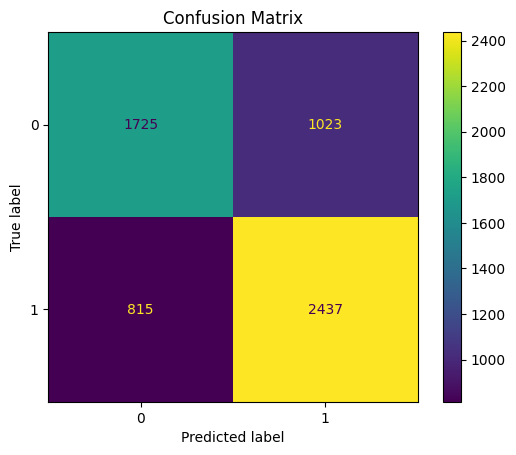

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix

The confusion matrix summarizes the model's predictions by comparing predicted labels with the actual labels.

It shows:

- True Positives
- True Negatives
- False Positives
- False Negatives

This helps identify the types of prediction errors made by the model.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.63      0.65      2748
           1       0.70      0.75      0.73      3252

    accuracy                           0.69      6000
   macro avg       0.69      0.69      0.69      6000
weighted avg       0.69      0.69      0.69      6000



### Classification Report

The classification report provides precision, recall, F1-score, and support for each class.

It offers a more detailed evaluation than overall accuracy by measuring performance separately for declining and non-declining pages.

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,impressions_90d,0.173024
9,avg_position,0.162067
3,content_age_days,0.118601
2,word_count,0.104519
7,sessions_90d,0.081945
11,scroll_rate,0.068901
8,ctr,0.064583
1,competition,0.053052
0,search_volume,0.052122
6,clicks_90d,0.051172


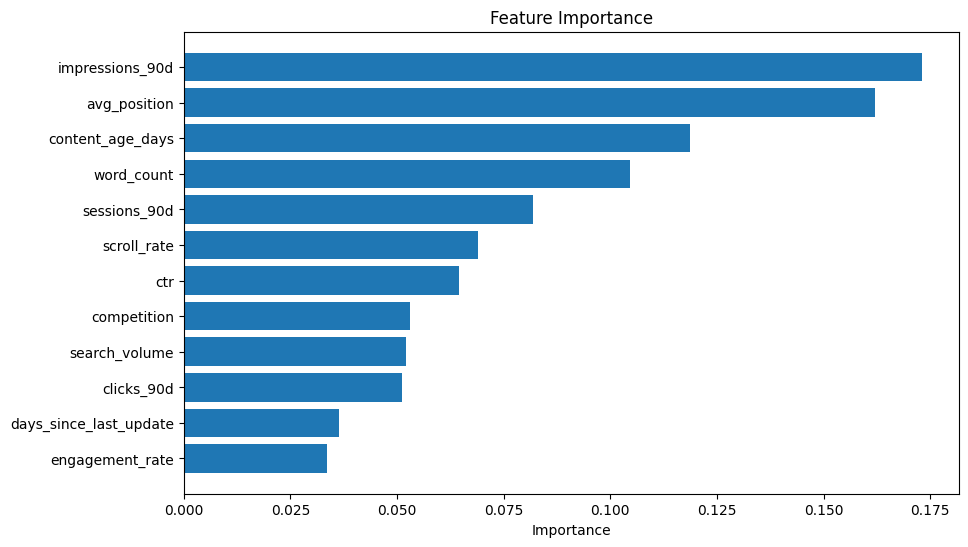

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.show()

### Feature Importance

Random Forest estimates the importance of each feature based on how much it contributes to reducing prediction error across all decision trees.

Features with higher importance have a greater influence on the model's predictions and provide insight into the key factors associated with declining content.

In [ ]:
import joblib

joblib.dump(
    rf_model,
    "refresh_prediction_model.pkl"
)

['refresh_prediction_model.pkl']

In [ ]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

## Summary

A Random Forest classifier was successfully trained to predict declining content pages.

The model was evaluated using standard classification metrics and a confusion matrix. Feature importance analysis identified the variables that contributed most to the predictions.

The trained model will be compared with the baseline scoring approach in the following section to determine whether machine learning provides improved decision support for content refresh prioritization.

# 7. Ranked Content Recommendations

The trained model and baseline scoring system were used to identify pages that should be prioritized for content refresh.

The highest-ranked pages are expected to provide the greatest opportunity for improving search visibility and user engagement.

In [ ]:
# Probability of declining content
df["decline_probability"] = rf_model.predict_proba(X)[:, 1]

In [ ]:
recommendations = df.sort_values(
    by="decline_probability",
    ascending=False
)

In [ ]:
recommendations = recommendations[
    [
        "content_id",
        "decline_probability",
        "baseline_refresh_score",
        "reason_codes",
        "suggested_action_baseline",
        "impressions_90d",
        "ctr",
        "avg_position",
        "content_age_days",
        "days_since_last_update"
    ]
]

In [ ]:
recommendations.head(10)

,content_id,decline_probability,baseline_refresh_score,reason_codes,suggested_action_baseline,impressions_90d,ctr,avg_position,content_age_days,days_since_last_update
27851,content_2cf20c4ba4db,1.0,0.447207,declining_with_demand,refresh,1001,0.00,26.1,168,20
21958,content_4521b26bd5ff,1.0,0.715104,declining_with_demand|low_engagement_visible_page,refresh,29125,0.75,19.6,147,20
4494,content_252c884e4400,1.0,0.708653,declining_with_demand|low_ctr_visible_page|low...,refresh_and_review_ctr,22537,0.36,15.9,147,20
8713,content_bfaaf0a4bbd3,1.0,0.690891,declining_with_demand|low_ctr_visible_page|low...,refresh_and_review_ctr,15213,0.34,18.0,141,20
4656,content_3065f33223c3,1.0,0.342727,declining_with_demand,refresh,282,0.00,6.2,141,20
4265,content_3f8c7aed9d6c,1.0,0.519572,declining_with_demand,refresh,328,0.00,3.0,165,104
28978,content_3f675f6f8ee2,1.0,0.700205,declining_with_demand|low_ctr_visible_page,refresh_and_review_ctr,15321,0.23,10.4,224,20
22666,content_2db43735a69a,1.0,0.728679,declining_with_demand|low_ctr_visible_page|low...,refresh_and_review_ctr,36130,0.40,11.1,225,20
17962,content_c64eead456d1,1.0,0.563454,declining_with_demand|low_ctr_visible_page,refresh_and_review_ctr,545,0.00,15.1,263,104
29655,content_2bb91729e4e1,1.0,0.657502,declining_with_demand,refresh,9811,0.07,21.8,224,20


In [ ]:
recommendations.to_csv(
    "top10_refresh_recommendations.csv",
    index=False
)

### Recommendation Summary

The pages with the highest predicted probability of decline were prioritized for review.

These recommendations combine the machine learning prediction with baseline scoring and reason codes, helping identify pages that are most likely to benefit from content updates.

# 8. Baseline vs Machine Learning

The baseline system uses predefined business rules to rank pages, while the Random Forest model learns patterns directly from historical data.

The machine learning model provides greater flexibility by automatically identifying complex relationships between search visibility, engagement, freshness, and ranking signals.

In [ ]:
comparison = pd.DataFrame({
    "Aspect":[
        "Approach",
        "Learns from Data",
        "Feature Importance",
        "Adaptability",
        "Interpretability"
    ],
    "Baseline":[
        "Rule-Based",
        "No",
        "No",
        "Low",
        "High"
    ],
    "Random Forest":[
        "Machine Learning",
        "Yes",
        "Yes",
        "High",
        "Medium"
    ]
})

comparison

,Aspect,Baseline,Random Forest
0,Approach,Rule-Based,Machine Learning
1,Learns from Data,No,Yes
2,Feature Importance,No,Yes
3,Adaptability,Low,High
4,Interpretability,High,Medium


# 9. Conclusion

This project developed a machine learning-based content opportunity scoring system to identify web pages that may require content refresh.

The workflow included data exploration, preprocessing, feature engineering, baseline scoring, and machine learning model development. A Random Forest classifier was trained using search performance, content quality, freshness, and engagement metrics.

The model achieved the following performance:

- Accuracy: **69.37%**
- Precision: **70.43%**
- Recall: **74.94%**
- F1-Score: **72.62%**

Feature importance analysis showed that **impressions**, **average search position**, **content age**, **word count**, and **sessions** were the most influential factors in predicting declining content.

Overall, the machine learning model provides a data-driven approach for identifying content refresh opportunities and supports better content optimization decisions.

# 10. Limitations

Although the model produced useful results, several limitations should be considered:

- The dataset is anonymized, so page URLs and actual content are unavailable.
- The target variable was derived from trend direction instead of manually labeled data.
- Only structured numerical and categorical features were used.
- The project evaluated a single machine learning algorithm (Random Forest).
- Additional features and longer historical data may further improve prediction performance.

# 11. Future Work

Future improvements could include:

- Evaluating advanced models such as XGBoost, LightGBM, or CatBoost.
- Incorporating Natural Language Processing (NLP) features extracted from page content.
- Developing a real-time dashboard for monitoring content performance.
- Automating content refresh recommendations using scheduled model predictions.
- Retraining the model periodically as new search data becomes available.

# 12. References

1. FlyRank Machine Learning Internship Dataset.
2. FlyRank – https://flyrank.ai
3. Scikit-learn Documentation
4. Pandas Documentation
5. NumPy Documentation
6. Matplotlib Documentation

In [ ]:
recommendations.to_csv(
    "top10_refresh_recommendations.csv",
    index=False
)

In [ ]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [ ]:
import joblib

joblib.dump(
    rf_model,
    "refresh_prediction_model.pkl"
)

['refresh_prediction_model.pkl']

# Acknowledgments

Built on the FlyRank Machine Learning Internship Dataset.

Data source:
https://flyrank.ai

This project was completed as part of the FlyRank Machine Learning Internship.